# Algorithm Testing

For each algorithm, before the comparisons with sklearn on time and various metrics, also analyze the data that is being used with `pandas` and by plotting it in as many shapes as possible. Visualize as much as possible.

Also, before doing any comparisons, check what happens when changing the hyperparameters in a controlled way, make plots of the various metrics with different values of the hyperparameters, try to find the best combination.

## Imports

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
from pathlib import Path

# Sets the working directory to the root, allowing to import from own files
sys.path.append(str(Path.cwd().parent))

In [17]:
%reload_ext autoreload
%autoreload 2
from models.knn import KNN
from models.linear_regression import LinearRegression
from models.logistic_regression import LogisticRegression
from models.decision_tree import DecisionTree
from models.random_forest import RandomForest
from models.naive_bayes import NaiveBayes
from models.pca import PCA
from models.perceptron import Perceptron
from models.svm import SVM

## KNN

In [20]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

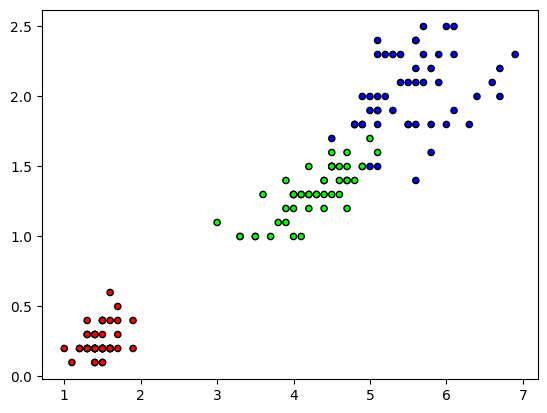

In [21]:
plt.figure()
plt.scatter(X[:,2], X[:,3], c=y, cmap = cmap, edgecolors='k', s=20)
plt.show()

In [22]:
clf = KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

In [23]:
acc = np.sum(predictions == y_test) / len(y_test)
acc

np.float64(0.9666666666666667)

## Linear Regression

In [24]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

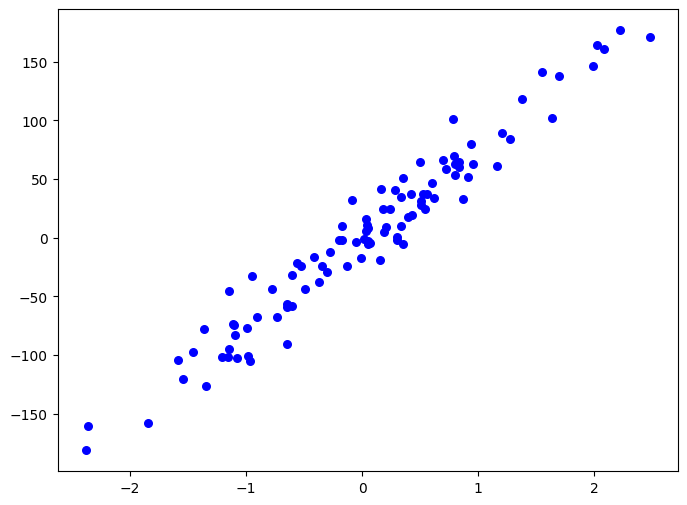

In [25]:
fig = plt.figure(figsize=(8,6))
plt.scatter(X[:,0], y, color='b', marker='o', s=30)
plt.show()

In [26]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
predictions = linreg.predict(X_test)

def mse(y_test, preds):
    return np.mean((y_test - preds)**2)

mse = mse(y_test, predictions)
print(mse)

361.2812896055198


Try with different learning rates. Also try with more features. Document results.

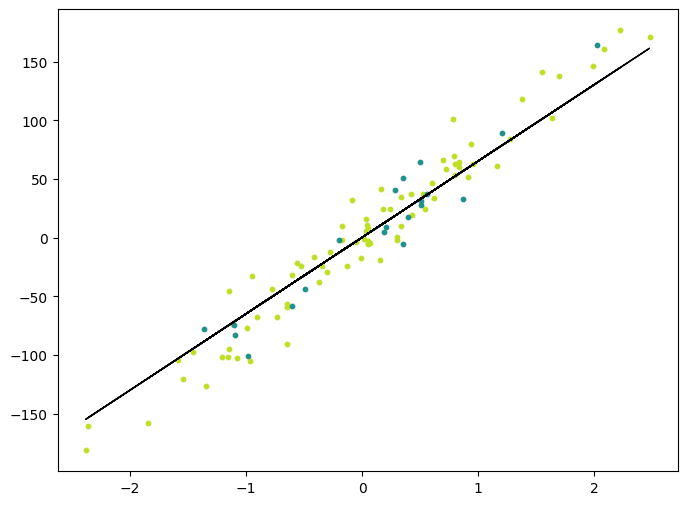

In [27]:
y_pred_line = linreg.predict(X)
cmap = plt.get_cmap('viridis')
fig = plt.figure(figsize=(8,6))
m1 = plt.scatter(X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(X_test, y_test, color=cmap(0.5), s=10)
plt.plot(X, y_pred_line, color='k', linewidth=1, label='Prediction')
plt.show()

## Logistic Regression

In [28]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [29]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [8]:
def accuracy_metric(y_pred, y_test):
    return np.sum(y_pred == y_test) / len(y_test)

In [31]:
print(accuracy_metric(y_pred, y_test))

0.9210526315789473


## Decision Tree

In [32]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [45]:
clf = DecisionTree(max_depth=100)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [46]:
print(accuracy_metric(y_pred, y_test))

0.9298245614035088


## Random Forest

In [47]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [53]:
clf = RandomForest(max_depth=100)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [54]:
print(accuracy_metric(y_pred, y_test))

0.9473684210526315


## Naive Bayes

In [65]:
X, y = datasets.make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=123
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [66]:
clf = NaiveBayes()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [67]:
print(accuracy_metric(y_pred, y_test))

0.965


## PCA

In [69]:
data = datasets.load_iris()
X = data.data
y = data.target

In [82]:
# Project the data onto the 2 primary principal components
clf = PCA(2)
clf.fit(X)
X_projected = clf.transform(X)

Shape of X: (150, 4)
Shape of transformed X: (150, 2)


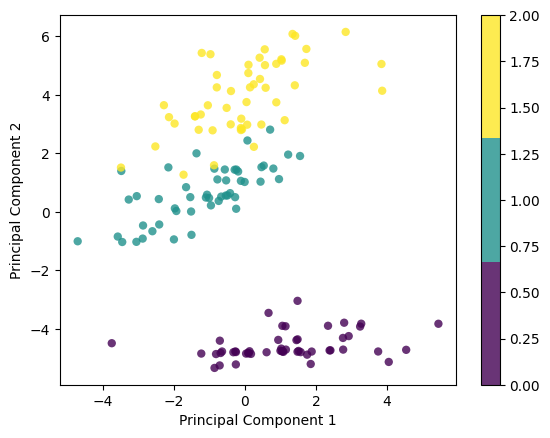

In [88]:
print("Shape of X:", X.shape)
print("Shape of transformed X:", X_projected.shape)

x1 = X_projected[:,0]
x2 = X_projected[:,1]

plt.scatter(x1, x2, c=y, edgecolors="none", alpha=0.8, cmap=plt.get_cmap("viridis", 3))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

## Perceptron

In [90]:
X, y = datasets.make_blobs(n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [93]:
clf = Perceptron(lr=0.01, n_iters=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [94]:
print(accuracy_metric(y_pred, y_test))

1.0


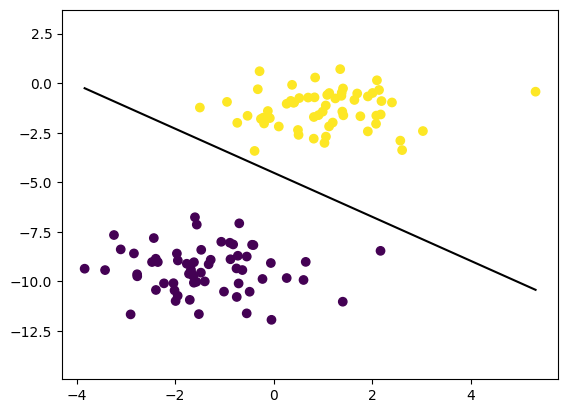

In [96]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train)

x0_1 = np.amin(X_train[:, 0])
x0_2 = np.amax(X_train[:, 0])

x1_1 = (-clf.weights[0] * x0_1 - clf.bias) / clf.weights[1]
x1_2 = (-clf.weights[0] * x0_2 - clf.bias) / clf.weights[1]

ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

ymin = np.amin(X_train[:, 1])
ymax = np.amax(X_train[:, 1])
ax.set_ylim([ymin - 3, ymax + 3])

plt.show()

## SVM

In [18]:
X, y = datasets.make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [19]:
clf = SVM(lr=0.01, lambda_param=0.01, n_iters=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [20]:
print(accuracy_metric(y_pred, y_test))

1.0


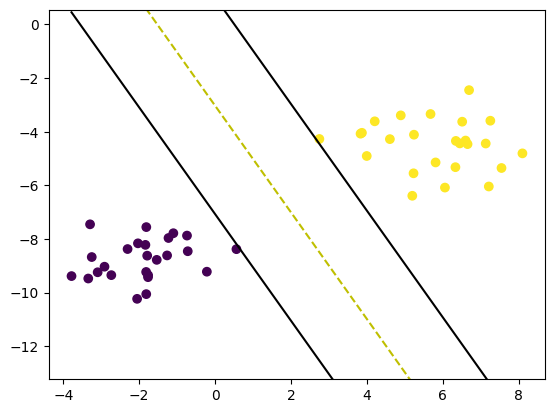

In [21]:
def visualize_svm():
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], marker="o", c=y)

    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])

    x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
    x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)

    x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "y--")
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k")
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k")

    x1_min = np.amin(X[:, 1])
    x1_max = np.amax(X[:, 1])
    ax.set_ylim([x1_min - 3, x1_max + 3])

    plt.show()

visualize_svm()